### Using XGBoost algorithm to predict final exam result of pass/fail

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

### 1. Load & Inspect Data

In [2]:
path = "student_performance_dataset.csv"
df = pd.read_csv(path)

print(df.shape)
df.head()

(708, 10)


,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [3]:
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nPass/Fail distribution:")
print(df["Pass_Fail"].value_counts())

Student_ID                        str
Gender                            str
Study_Hours_per_Week            int64
Attendance_Rate               float64
Past_Exam_Scores                int64
Parental_Education_Level          str
Internet_Access_at_Home           str
Extracurricular_Activities        str
Final_Exam_Score                int64
Pass_Fail                         str
dtype: object

Missing values:
Student_ID                    0
Gender                        0
Study_Hours_per_Week          0
Attendance_Rate               0
Past_Exam_Scores              0
Parental_Education_Level      0
Internet_Access_at_Home       0
Extracurricular_Activities    0
Final_Exam_Score              0
Pass_Fail                     0
dtype: int64

Pass/Fail distribution:
Pass_Fail
Pass    354
Fail    354
Name: count, dtype: int64


### 2. Preprocessing

In [4]:
df_processed = df.copy()

# Drop ID column and Final_Exam_Score column
df_processed = df_processed.drop(columns=["Student_ID"])
df_processed = df_processed.drop(columns=["Final_Exam_Score"])

#Target encoding
df_processed["Pass_Fail"] = df_processed["Pass_Fail"].map({"Pass": 1, "Fail": 0})

#Ordinal encoding for education level
education_map = {"High School": 0, "Bachelors": 1, "Masters": 2, "PhD": 3}
df_processed["Parental_Education_Level"] = df_processed["Parental_Education_Level"].map(education_map)

#Binary encodings
binary_map = {"Yes": 1, "No": 0}
df_processed["Internet_Access_at_Home"] = df_processed["Internet_Access_at_Home"].map(binary_map)
df_processed["Extracurricular_Activities"] = df_processed["Extracurricular_Activities"].map(binary_map)

#One-hot encode Gender
df_processed = pd.get_dummies(df_processed, columns=["Gender"], drop_first=True)
df_processed["Gender_Male"] = df_processed["Gender_Male"].astype(int)

print("Final columns:", list(df_processed.columns))
df_processed.head()

Final columns: ['Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores', 'Parental_Education_Level', 'Internet_Access_at_Home', 'Extracurricular_Activities', 'Pass_Fail', 'Gender_Male']


,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Pass_Fail,Gender_Male
0,31,68.267841,86,0,1,1,1,1
1,16,78.222927,73,3,0,0,0,1
2,21,87.525096,74,3,1,0,0,0
3,27,92.076483,99,1,0,0,1,0
4,37,98.655517,63,2,0,1,1,0


### 3. Feature / Target Split

In [5]:
# Explicitly name features to avoid accidental column order bugs
feature_cols = [c for c in df_processed.columns if c != "Pass_Fail"]
X = df_processed[feature_cols].values
y = df_processed["Pass_Fail"].values

print("Features:", feature_cols)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class balance — Pass:", y.sum(), "/ Fail:", (y == 0).sum())

Features: ['Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores', 'Parental_Education_Level', 'Internet_Access_at_Home', 'Extracurricular_Activities', 'Gender_Male']
X shape: (708, 7)
y shape: (708,)
Class balance — Pass: 354 / Fail: 354


### 4. Train / Test Split

In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(566, 7) (142, 7)


### 5. Baseline XGBoost (default params)

In [7]:
baseline = XGBClassifier(random_state=42, eval_metric="logloss")
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)
print(f"Baseline Accuracy : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Baseline ROC-AUC  : {roc_auc_score(y_test, y_pred_base):.4f}")

Baseline Accuracy : 0.8592
Baseline ROC-AUC  : 0.8592


### 6. Hyperparameter Tuning with GridSearchCV

In [8]:
param_grid = {
    "n_estimators":       [100, 200, 300],
    "max_depth":          [3, 4, 5, 6],
    "learning_rate":      [0.01, 0.05, 0.1, 0.2],
    "subsample":          [0.7, 0.8, 1.0],
    "colsample_bytree":   [0.7, 0.8, 1.0],
    "min_child_weight":   [1, 3, 5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}
Best CV ROC-AUC: 0.9600


### 7. Evaluate Best Model

In [9]:
best_model = grid_search.best_estimator_

y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(f"Tuned Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Tuned ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Fail", "Pass"]))

Tuned Accuracy : 0.8803
Tuned ROC-AUC  : 0.9518

              precision    recall  f1-score   support

        Fail       0.97      0.79      0.87        71
        Pass       0.82      0.97      0.89        71

    accuracy                           0.88       142
   macro avg       0.89      0.88      0.88       142
weighted avg       0.89      0.88      0.88       142



In [10]:
# Cross-validation on the full training set with the best estimator
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"CV ROC-AUC scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}")

CV ROC-AUC scores: [0.96552785 0.92136591 0.98934837 0.96209273 0.95958647]
Mean: 0.9596  Std: 0.0219


### 8. Confusion Matrix

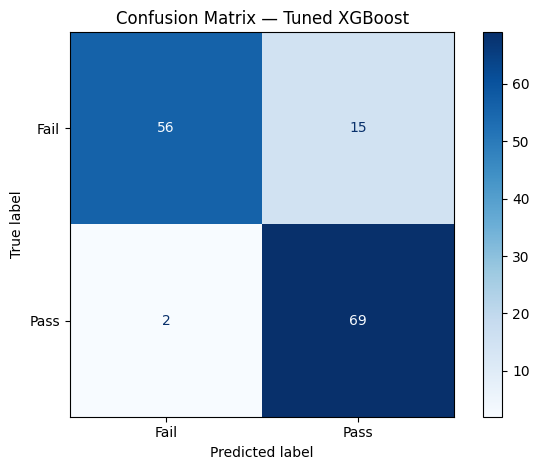

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fail", "Pass"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Tuned XGBoost")
plt.tight_layout()
plt.show()

### 9. Feature Importance

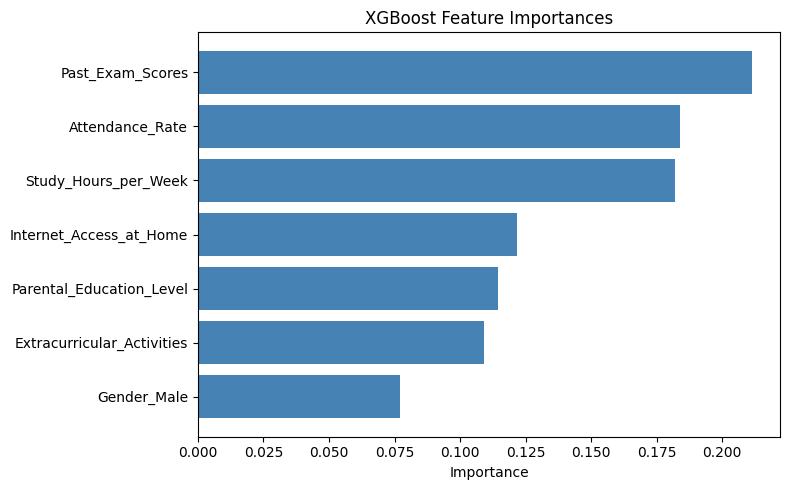

In [12]:
importances = best_model.feature_importances_
feat_df = pd.DataFrame({"Feature": feature_cols, "Importance": importances})
feat_df = feat_df.sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df["Feature"], feat_df["Importance"], color="steelblue")
plt.xlabel("Importance")
plt.title("XGBoost Feature Importances")
plt.tight_layout()
plt.show()